In [1]:
!pip install -q streamlit shap matplotlib seaborn scipy joblib scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# MediTrack — Gradient Boosting Module
### 30-Day Readmission Risk: Model, Explainability, Database, RAG Assistant, App

This notebook is your complete, self-contained submission for the **Gradient Boosting** track of the MediTrack project (CP-02).

It covers, in order:
1. Data cleaning & exclusion rules
2. Exploratory analysis with statistical tests
3. Feature engineering (diagnosis grouping, medication changes)
4. Train/test split, class imbalance handling
5. Gradient Boosting model training & baseline evaluation
6. Decision threshold tuning (clinical justification)
7. Patient-level explainability (SHAP)
8. High-risk cohort list for the care team
9. Relational database (SQLite) + required SQL queries
10. RAG-style discharge assistant + safety guardrails
11. Saving model artifacts
12. Streamlit application (`app.py`)
13. Deployment notes (a stable, presentable public link)

**Before running:** upload `diabetic_data.csv` to this notebook's file browser (or mount Drive and update the path in Step 0).



## Step 0 — Load Libraries & Data


In [2]:
# Step 1 — Load the Full Canonical Dataset
import pandas as pd
import numpy as np
import os

# Import shared preprocessing for canonical split & feature consistency
import sys
sys.path.insert(0, '.')
from shared_preprocessing import (
    get_classical_split, prepare_classical_features,
    FEATURES, OHE_COLUMNS, MEDICATION_COLS
)

data_path = 'diabetic_data.csv'
if not os.path.exists(data_path):
    data_path = '../diabetic_data.csv'

df = pd.read_csv(data_path)
print('Raw dataset shape:', df.shape)
df.head()

Raw dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Step 1 — Data Cleaning & Exclusion Rules

**What we do:** remove deceased/hospice discharges (they had no chance of being readmitted),
drop columns that are almost entirely missing (`weight`, `payer_code`, `medical_specialty`),
and convert the 3-class `readmitted` column into the binary target the brief asks for
(30-day readmission = 1, everything else = 0).

**Why:** the brief explicitly requires documented exclusion rules for deceased/hospice
discharges and explicit handling of the missing `weight`/`payer` fields.



In [3]:
# discharge_disposition_id 11, 13, 14, 19, 20, 21 = expired / hospice
EXCLUDE_DISCHARGE_IDS = [11, 13, 14, 19, 20, 21]

df_clean = df[~df['discharge_disposition_id'].isin(EXCLUDE_DISCHARGE_IDS)].copy()
print(f"Shape after excluding deceased/hospice discharges: {df_clean.shape}")

# weight is ~97% missing, payer_code ~40% missing, medical_specialty ~49% missing.
# Documented decision: drop rather than impute, since imputing that much data
# would manufacture information we don't have.
df_clean.drop(columns=['weight', 'payer_code', 'medical_specialty'], inplace=True)

# Binary target: 1 = readmitted within 30 days, 0 = not readmitted / readmitted later
df_clean['risk_target'] = (df_clean['readmitted'] == '<30').astype(int)
df_clean.drop(columns=['readmitted'], inplace=True)

print("\nTarget distribution:")
print(df_clean['risk_target'].value_counts())
print("\nPercentage:")
print((df_clean['risk_target'].value_counts(normalize=True) * 100).round(2))



Shape after excluding deceased/hospice discharges: (99343, 50)

Target distribution:
risk_target
0    88029
1    11314
Name: count, dtype: int64

Percentage:
risk_target
0    88.61
1    11.39
Name: proportion, dtype: float64


## Step 2 — Establishing the Base Rate & Statistical Analysis

The brief requires the readmission base rate to be established, and tested against
age group, admission type, and prior inpatient history, **with a statistical basis**
(not just a chart). Since all three variables are categorical/discrete, a
Chi-Square Test of Independence is the correct tool.



In [4]:
import scipy.stats as stats

base_rate = df_clean['risk_target'].mean() * 100
print(f"Overall 30-day readmission base rate: {base_rate:.2f}%\n")
print("=" * 55)

columns_to_test = {
    'Age Group': 'age',
    'Admission Type': 'admission_type_id',
    'Prior Inpatient History': 'number_inpatient',
}

chi_square_results = []
for label, col in columns_to_test.items():
    contingency_table = pd.crosstab(df_clean[col], df_clean['risk_target'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    significant = p_value < 0.05
    chi_square_results.append({'Variable': label, 'Chi2': round(chi2, 2), 'p-value': p_value, 'Significant (p<0.05)': significant})
    print(f"--- {label} ({col}) ---")
    print(f"Chi2 = {chi2:.2f}, p-value = {p_value:.2e}")
    print("Conclusion:", "STATISTICALLY SIGNIFICANT" if significant else "Not significant")
    print("-" * 55)

chi_square_df = pd.DataFrame(chi_square_results)
chi_square_df



Overall 30-day readmission base rate: 11.39%

--- Age Group (age) ---
Chi2 = 133.60, p-value = 2.15e-24
Conclusion: STATISTICALLY SIGNIFICANT
-------------------------------------------------------
--- Admission Type (admission_type_id) ---
Chi2 = 32.59, p-value = 3.16e-05
Conclusion: STATISTICALLY SIGNIFICANT
-------------------------------------------------------
--- Prior Inpatient History (number_inpatient) ---
Chi2 = 2882.47, p-value = 0.00e+00
Conclusion: STATISTICALLY SIGNIFICANT
-------------------------------------------------------


,Variable,Chi2,p-value,Significant (p<0.05)
0,Age Group,133.60,2.154572e-24,True
1,Admission Type,32.59,3.158305e-05,True
2,Prior Inpatient History,2882.47,0.000000e+00,True



icd9_official_descriptions = {
    '428': 'congestive heart failure left ventricular failure cardiac insufficiency',
    '414': 'coronary atherosclerosis chronic ischemic heart disease coronary artery disease',
    '786': 'symptoms involving respiratory system chest pain dyspnea shortness of breath',
    '410': 'acute myocardial infarction heart attack coronary thrombosis',
    '486': 'pneumonia organism unspecified lower respiratory tract infection',
    '427': 'cardiac dysrhythmias atrial fibrillation flutter heart rhythm disorder',
    '491': 'chronic bronchitis chronic obstructive pulmonary disease copd',
    '715': 'osteoarthrosis osteoarthritis degenerative joint disease',
    '682': 'other cellulitis and abscess acute skin infection',
    '434': 'occlusion of cerebral arteries acute ischemic stroke cerebrovascular accident',
    '276': 'disorders of fluid electrolyte and acid base balance dehydration hyponatremia',
    '250': 'diabetes mellitus with vascular manifestations uncontrolled blood glucose hyperosmolality',
    '401': 'essential primary hypertension high blood pressure',
    '496': 'chronic airway obstruction not elsewhere classified copd lung disease',
    '599': 'urinary tract infection kidney urethra bladder inflammation',
    '403': 'hypertensive chronic kidney disease renal disease',
    '411': 'other acute and subacute forms of ischemic heart disease unstable angina',
    '585': 'chronic kidney disease renal failure end stage renal disease',
    '272': 'disorders of lipoid metabolism hyperlipidemia hypercholesterolemia'
}

## Step 3 — Feature Engineering

**Diagnosis grouping:** `diag_1`/`diag_2`/`diag_3` contain hundreds of raw ICD-9 codes.
Feeding these directly into the model would create unusable high-cardinality features,
so they are grouped into 9 clinically meaningful categories (Circulatory, Respiratory, etc.),
which is exactly what the brief means by "handle high-cardinality diagnosis codes".

**Medication changes:** the dataset has 23 separate medication columns. Rather than
one-hot encoding all of them (which would add ~70 sparse columns), we compress them
into a single, more informative feature: how many medications were adjusted (`Up`/`Down`)
during the stay. This is the "handle inconsistent medication entries" requirement.



In [5]:

icd9_official_descriptions = {
    '428': 'congestive heart failure left ventricular failure cardiac insufficiency',
    '414': 'coronary atherosclerosis chronic ischemic heart disease coronary artery disease',
    '786': 'symptoms involving respiratory system chest pain dyspnea shortness of breath',
    '410': 'acute myocardial infarction heart attack coronary thrombosis',
    '486': 'pneumonia organism unspecified lower respiratory tract infection',
    '427': 'cardiac dysrhythmias atrial fibrillation flutter heart rhythm disorder',
    '491': 'chronic bronchitis chronic obstructive pulmonary disease copd',
    '715': 'osteoarthrosis osteoarthritis degenerative joint disease',
    '682': 'other cellulitis and abscess acute skin infection',
    '434': 'occlusion of cerebral arteries acute ischemic stroke cerebrovascular accident',
    '276': 'disorders of fluid electrolyte and acid base balance dehydration hyponatremia',
    '250': 'diabetes mellitus with vascular manifestations uncontrolled blood glucose hyperosmolality',
    '401': 'essential primary hypertension high blood pressure',
    '496': 'chronic airway obstruction not elsewhere classified copd lung disease',
    '599': 'urinary tract infection kidney urethra bladder inflammation',
    '403': 'hypertensive chronic kidney disease renal disease',
    '411': 'other acute and subacute forms of ischemic heart disease unstable angina',
    '585': 'chronic kidney disease renal failure end stage renal disease',
    '272': 'disorders of lipoid metabolism hyperlipidemia hypercholesterolemia'
}

def group_diagnosis(code):
    """Map a raw ICD-9 diagnosis code to one of 9 broad clinical categories."""
    if pd.isna(code):
        return 'Missing'
    if isinstance(code, str) and (code.startswith('V') or code.startswith('E')):
        return 'Other'
    try:
        code_num = float(code)
    except ValueError:
        return 'Other'

    if 390 <= code_num <= 459 or code_num == 785:
        return 'Circulatory'
    elif 460 <= code_num <= 519 or code_num == 786:
        return 'Respiratory'
    elif 520 <= code_num <= 579 or code_num == 787:
        return 'Digestive'
    elif code_num == 250:
        return 'Diabetes'
    elif 800 <= code_num <= 999:
        return 'Injury'
    elif 710 <= code_num <= 739:
        return 'Musculoskeletal'
    elif 580 <= code_num <= 629 or code_num == 788:
        return 'Genitourinary'
    elif 140 <= code_num <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

df_clean['primary_diagnosis_group'] = df_clean['diag_1'].apply(group_diagnosis)

MEDICATION_COLS = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone',
]

df_clean['num_medication_changes'] = df_clean[MEDICATION_COLS].apply(
    lambda row: ((row == 'Up') | (row == 'Down')).sum(), axis=1
)

print("Feature engineering complete.")
print(df_clean['primary_diagnosis_group'].value_counts())



Feature engineering complete.
primary_diagnosis_group
Circulatory        29681
Other              26239
Respiratory        13934
Digestive           9333
Injury              6853
Genitourinary       5002
Musculoskeletal     4935
Neoplasms           3131
Diabetes             235
Name: count, dtype: int64


## Step 4 — Train/Test Split & Class Imbalance

Only ~11.4% of encounters are positive (readmitted within 30 days), so we need to
tell the model to pay more attention to that minority class.

**Justification for class weighting over resampling:** undersampling would throw away
~78,000 majority-class rows we don't need to discard, and SMOTE-style oversampling
synthesizes fake patient records, which is hard to defend clinically. Class weighting
keeps every real row and simply penalizes the model more for missing a positive case —
this is the documented choice the brief asks for.



In [6]:
# Step 4 — Canonical 3-way Stratified Split (64/16/20) & Class Imbalance
# Use shared canonical split to ensure IDENTICAL test set across LR/RF/GB/NB
from sklearn.model_selection import train_test_split

y = df_clean['risk_target']

# Canonical 3-way split: 64% train, 16% validation, 20% test
train_idx, val_idx, test_idx = get_classical_split(df_clean.index, y)

# One-hot encoding fitted on TRAINING DATA ONLY (prevents vocabulary leakage)
X_train, X_val, X_test, y_train, y_val, y_test = prepare_classical_features(
    df_clean, train_idx, val_idx, test_idx
)

print('Training shape:', X_train.shape, '  Validation shape:', X_val.shape, '  Testing shape:', X_test.shape)
print(f'Train positive rate: {y_train.mean():.4f}')
print(f'Val positive rate:   {y_val.mean():.4f}')
print(f'Test positive rate:  {y_test.mean():.4f}')
print(f'\nCanonical test encounters: {len(test_idx)}')
print(f'Class imbalance handled via class_weight="balanced" in model training')

Training shape: (63579, 28)   Validation shape: (15895, 28)   Testing shape: (19869, 28)
Train positive rate: 0.1139
Val positive rate:   0.1139
Test positive rate:  0.1139

Canonical test encounters: 19869
Class imbalance handled via class_weight="balanced" in model training


## Step 5 — Train the Gradient Boosting Model

We use `HistGradientBoostingClassifier` (fast, native categorical/NaN handling,
built-in `class_weight='balanced'` support) and evaluate with Recall, Precision,
F1 and ROC-AUC rather than accuracy — accuracy is misleading here, since predicting
"never readmitted" for everyone would score ~88.6% accuracy while catching zero
at-risk patients.



In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

gb_model = HistGradientBoostingClassifier(
    class_weight='balanced',
    max_iter=100,
    random_state=42,
)

print("Training Gradient Boosting model...")
gb_model.fit(X_train, y_train)
print("Training complete.\n")

# Validation predictions (for threshold selection)
y_val_proba = gb_model.predict_proba(X_val)[:, 1]
val_roc_auc = roc_auc_score(y_val, y_val_proba)
print(f"Validation ROC-AUC: {val_roc_auc:.4f}")

# Test predictions (for FINAL evaluation only)
y_pred_proba = gb_model.predict_proba(X_test)[:, 1]
y_pred_default = (y_pred_proba >= 0.50).astype(int)

print("=" * 50)
print("EVALUATION AT DEFAULT THRESHOLD (0.50) — FINAL TEST")
print("=" * 50)
print(classification_report(y_test, y_pred_default, digits=3))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("-" * 50)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_default))

Training Gradient Boosting model...


Training complete.

Validation ROC-AUC: 0.6390
EVALUATION AT DEFAULT THRESHOLD (0.50) — FINAL TEST
              precision    recall  f1-score   support

           0      0.918     0.640     0.754     17606
           1      0.165     0.555     0.255      2263

    accuracy                          0.630     19869
   macro avg      0.542     0.598     0.504     19869
weighted avg      0.832     0.630     0.697     19869

ROC-AUC Score: 0.6405
--------------------------------------------------
Confusion Matrix:
 [[11262  6344]
 [ 1006  1257]]


## Step 6 — Decision Threshold Tuning (Clinical Justification)

The brief requires the threshold to be **explicitly tuned and defended**, not left at
the default 0.50. In healthcare, a **false negative** (discharging a high-risk patient
who is never flagged) is far more costly than a **false positive** (an extra follow-up
call to someone who turns out fine) — so we deliberately trade some precision for recall.



In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# --- Threshold selection on VALIDATION data (not test) ---
threshold_candidates = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
rows = []
for t in threshold_candidates:
    preds = (y_val_proba >= t).astype(int)
    rows.append({
        'Threshold': t,
        'Val Recall': round(recall_score(y_val, preds, zero_division=0), 3),
        'Val Precision': round(precision_score(y_val, preds, zero_division=0), 3),
        'Val F1': round(f1_score(y_val, preds, zero_division=0), 3),
        'Val Flagged': int(preds.sum()),
    })

threshold_df = pd.DataFrame(rows)
print("CLINICAL THRESHOLD OPTIMIZATION MATRIX (VALIDATION SET — Gradient Boosting)")
print(threshold_df.to_string(index=False))

# Select threshold that maximizes F1 on validation
CHOSEN_THRESHOLD = threshold_df.loc[threshold_df['Val F1'].idxmax(), 'Threshold']
print(f"\n>>> Selected threshold (max Val F1): {CHOSEN_THRESHOLD}")

# FREEZE threshold and evaluate on FINAL TEST SET
y_chosen = (y_pred_proba >= CHOSEN_THRESHOLD).astype(int)
print(f"\n=== FINAL TEST at Frozen Threshold ({CHOSEN_THRESHOLD}) ===")
print(classification_report(y_test, y_chosen, target_names=['No 30d Readmit', '30d Readmit']))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Test PR-AUC:  {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"Encounters flagged: {y_chosen.sum()} / {len(y_chosen)} ({y_chosen.mean():.1%})")

CLINICAL THRESHOLD OPTIMIZATION MATRIX (VALIDATION SET — Gradient Boosting)
 Threshold  Val Recall  Val Precision  Val F1  Val Flagged
      0.35       0.903          0.126   0.222        12924
      0.40       0.821          0.135   0.232        10974
      0.45       0.715          0.147   0.245         8783
      0.50       0.565          0.167   0.258         6113
      0.55       0.390          0.194   0.259         3643
      0.60       0.269          0.224   0.244         2178

>>> Selected threshold (max Val F1): 0.55

=== FINAL TEST at Frozen Threshold (0.55) ===
                precision    recall  f1-score   support

No 30d Readmit       0.91      0.79      0.85     17606
   30d Readmit       0.20      0.39      0.26      2263

      accuracy                           0.75     19869
     macro avg       0.55      0.59      0.55     19869
  weighted avg       0.83      0.75      0.78     19869

Test ROC-AUC: 0.6405
Test PR-AUC:  0.2067
Encounters flagged: 4495 / 19869 (22.6%)

## Step 7 — Patient-Level Explainability (SHAP)

The brief requires a **factor-level explanation for each patient**, not just a score.
We use SHAP to break down exactly how much each feature pushed an individual patient's
risk up or down.

> **Fix applied:** `pd.get_dummies` produces boolean columns in recent pandas versions,
> which crashes SHAP's internal math (`TypeError: ufunc 'isfinite' not supported`).
> We cast the data to `float` before handing it to the explainer — this is the fix,
> already applied below, so this cell will run cleanly.



C:\Users\Simran Sanya\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initializing SHAP explainer on a background sample...
Generating SHAP explanation for Test Encounter ID: 28778...


PermutationExplainer explainer: 100%|██████████| 1/1 [00:00<?, ?it/s]

PermutationExplainer explainer: 2it [00:13, 13.84s/it]               

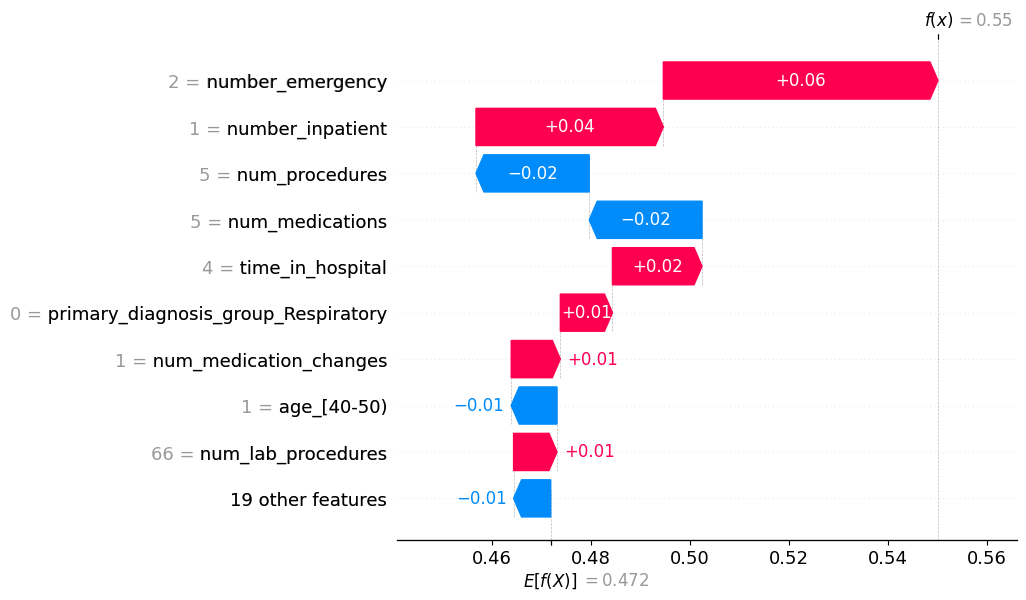


--- TOP CONTRIBUTING RISK FACTORS FOR THIS PATIENT ---
- number_emergency (value: 2.0): INCREASED risk by 0.0554
- number_inpatient (value: 1.0): INCREASED risk by 0.0378
- num_procedures (value: 5.0): DECREASED risk by 0.0229
- num_medications (value: 5.0): DECREASED risk by 0.0228
- time_in_hospital (value: 4.0): INCREASED risk by 0.0181


In [9]:
import shap
import matplotlib.pyplot as plt

# Cast to float — required so SHAP doesn't choke on boolean one-hot columns
X_train_shap = X_train.astype(float)
X_test_shap = X_test.astype(float)

print("Initializing SHAP explainer on a background sample...")
background_sample = X_train_shap.sample(100, random_state=42)
prob_func = lambda x: gb_model.predict_proba(x)[:, 1]
explainer = shap.Explainer(prob_func, background_sample)

# Pick a patient the model flagged as high risk at our chosen threshold
flagged_indices = y_test[(y_test == 1) & (y_pred_proba >= CHOSEN_THRESHOLD)].index
sample_patient_idx = flagged_indices[0]
sample_patient_data = X_test_shap.loc[[sample_patient_idx]]

print(f"Generating SHAP explanation for Test Encounter ID: {sample_patient_idx}...")
shap_values = explainer(sample_patient_data)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0], max_display=10, show=True)

feature_names = X_test.columns
patient_shap = shap_values[0].values
top_indices = np.argsort(np.abs(patient_shap))[::-1][:5]

print("\n--- TOP CONTRIBUTING RISK FACTORS FOR THIS PATIENT ---")
for idx in top_indices:
    direction = "INCREASED risk" if patient_shap[idx] > 0 else "DECREASED risk"
    val = sample_patient_data.iloc[0, idx]
    print(f"- {feature_names[idx]} (value: {val}): {direction} by {abs(patient_shap[idx]):.4f}")



Computing SHAP values for a sample of the test set (this may take a minute)...


PermutationExplainer explainer:  24%|██▍       | 72/300 [00:00<?, ?it/s]

PermutationExplainer explainer:  25%|██▍       | 74/300 [00:10<00:17, 13.00it/s]

PermutationExplainer explainer:  25%|██▌       | 76/300 [00:10<00:22,  9.97it/s]

PermutationExplainer explainer:  26%|██▌       | 78/300 [00:10<00:24,  9.01it/s]

...

PermutationExplainer explainer:  98%|█████████▊| 294/300 [00:32<00:00, 10.15it/s]

PermutationExplainer explainer:  99%|█████████▊| 296/300 [00:32<00:00, 10.12it/s]

PermutationExplainer explainer:  99%|█████████▉| 298/300 [00:33<00:00, 10.17it/s]

PermutationExplainer explainer: 100%|██████████| 300/300 [00:33<00:00, 10.20it/s]

PermutationExplainer explainer: 301it [00:33,  6.85it/s]                         

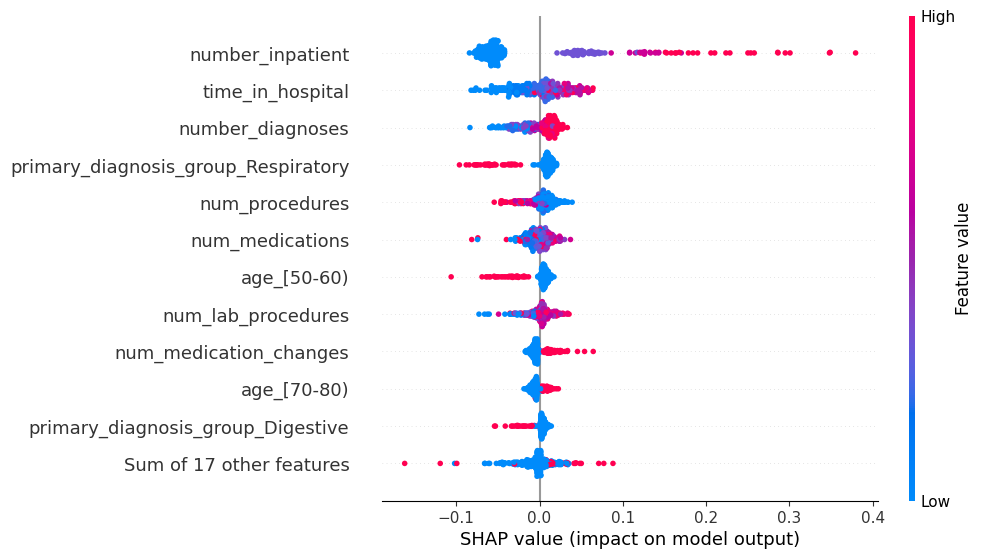

In [10]:
# Global feature importance — which factors matter most across ALL patients,
# not just one. Good supporting evidence for your defense.
print("Computing SHAP values for a sample of the test set (this may take a minute)...")
sample_for_summary = X_test_shap.sample(min(300, len(X_test_shap)), random_state=42)
shap_values_summary = explainer(sample_for_summary)

plt.figure(figsize=(9, 6))
shap.plots.beeswarm(shap_values_summary, max_display=12, show=True)



## Step 8 — High-Risk Cohort List for the Care Team

The brief's functionality checklist explicitly requires a **high-risk cohort list**.
This produces a ranked table of the test-set encounters flagged at our chosen threshold,
which is exactly what a discharge nurse would triage from each morning.



In [11]:
high_risk_cohort = X_test.copy()
high_risk_cohort['readmission_risk_score'] = y_pred_proba
high_risk_cohort['actual_outcome'] = y_test.values
high_risk_cohort = high_risk_cohort[high_risk_cohort['readmission_risk_score'] >= CHOSEN_THRESHOLD]
high_risk_cohort = high_risk_cohort.sort_values('readmission_risk_score', ascending=False)

print(f"High-risk cohort size: {len(high_risk_cohort)} of {len(X_test)} test encounters "
      f"({len(high_risk_cohort) / len(X_test) * 100:.1f}%)")

cohort_view = high_risk_cohort[[
    'time_in_hospital', 'number_inpatient', 'number_emergency',
    'num_medication_changes', 'readmission_risk_score'
]].head(15).copy()
cohort_view['readmission_risk_score'] = (cohort_view['readmission_risk_score'] * 100).round(1)
cohort_view.rename(columns={'readmission_risk_score': 'Risk Score (%)'}, inplace=True)
cohort_view



High-risk cohort size: 4495 of 19869 test encounters (22.6%)


,time_in_hospital,number_inpatient,number_emergency,num_medication_changes,Risk Score (%)
26412,6.0,13.0,4.0,1.0,89.3
79467,1.0,12.0,5.0,1.0,89.3
88075,1.0,15.0,2.0,1.0,89.0
53771,2.0,13.0,1.0,1.0,88.8
23306,7.0,12.0,0.0,1.0,88.4
95143,11.0,13.0,2.0,0.0,88.3
74441,2.0,11.0,9.0,0.0,88.2
33532,1.0,12.0,3.0,0.0,87.9
101030,2.0,11.0,2.0,0.0,87.8
22430,10.0,12.0,0.0,0.0,87.3


## Step 9 — Relational Database & SQL Queries

The brief requires a relational model covering encounters, diagnoses, and medications,
plus specific queries: **readmission rate by cohort**, **average stay by diagnosis group**,
and **patient encounter sequences**. We build this as an in-memory SQLite database here;
the same schema/SQL can be pointed at a real Postgres/MySQL instance for the submitted
SQL files.



In [12]:
import sqlite3

conn = sqlite3.connect(':memory:')

encounter_df = df_clean[['encounter_id', 'patient_nbr', 'admission_type_id', 'time_in_hospital', 'risk_target']]
encounter_df.to_sql('ENCOUNTER', conn, index=False, if_exists='replace')

diagnosis_df = df_clean[['encounter_id', 'primary_diagnosis_group']]
diagnosis_df.to_sql('DIAGNOSIS', conn, index=False, if_exists='replace')

print("Tables ENCOUNTER and DIAGNOSIS created.\n")

# Query 1: readmission rate & average stay by diagnosis group (cohort)
query_cohort = """
SELECT
    d.primary_diagnosis_group AS "Diagnosis Category",
    COUNT(e.encounter_id)     AS "Total Patients",
    ROUND(AVG(e.time_in_hospital), 2) AS "Avg Length of Stay (Days)",
    ROUND(AVG(e.risk_target) * 100, 2) AS "Readmission Rate (%)"
FROM ENCOUNTER e
JOIN DIAGNOSIS d ON e.encounter_id = d.encounter_id
GROUP BY d.primary_diagnosis_group
ORDER BY "Readmission Rate (%)" DESC;
"""
print("--- Readmission rate & avg stay by diagnosis group ---")
cohort_result = pd.read_sql_query(query_cohort, conn)
print(cohort_result.to_string(index=False))

# Query 2: patient encounter sequences (patients with multiple visits)
query_sequences = """
SELECT
    patient_nbr,
    COUNT(encounter_id) AS num_encounters,
    SUM(risk_target)    AS times_readmitted_within_30d
FROM ENCOUNTER
GROUP BY patient_nbr
HAVING num_encounters > 1
ORDER BY num_encounters DESC
LIMIT 10;
"""
print("\n--- Patient encounter sequences (repeat patients) ---")
sequence_result = pd.read_sql_query(query_sequences, conn)
print(sequence_result.to_string(index=False))



Tables ENCOUNTER and DIAGNOSIS created.

--- Readmission rate & avg stay by diagnosis group ---
Diagnosis Category  Total Patients  Avg Length of Stay (Days)  Readmission Rate (%)
            Injury            6853                       4.62                 12.40
             Other           26239                       4.64                 12.21
       Circulatory           29681                       4.21                 11.69
     Genitourinary            5002                       4.22                 11.04
         Neoplasms            3131                       5.28                 10.89
         Digestive            9333                       4.36                 10.82
       Respiratory           13934                       4.19                 10.06
   Musculoskeletal            4935                       3.91                  9.54
          Diabetes             235                       2.77                  6.81

--- Patient encounter sequences (repeat patients) ---


 patient_nbr  num_encounters  times_readmitted_within_30d
    88785891              40                           23
    43140906              28                           22
    88227540              23                           12
    23199021              23                            7
     1660293              23                           11
    84428613              22                           12
    23643405              22                           12
    92709351              21                           12
    90609804              20                            7
    89472402              20                           11


## Step 10 — RAG-Style Discharge Assistant & Safety Guardrails

The brief requires the assistant to (a) retrieve guideline content grounded to the
patient's diagnosis, (b) generate a discharge summary **with citations**, and
(c) **refuse** diagnostic/prescriptive requests. This cell simulates the guardrail
and retrieval-prompt construction; in the real application this prompt gets sent to
an LLM via the API (see the docx `product-self-knowledge` note in the README about
wiring this to Claude/another LLM with actual document retrieval).



In [13]:
def test_ai_guardrails(user_prompt: str) -> str:
    forbidden_intents = ['diagnose', 'prescribe', 'what medicine', 'treatment plan', 'which drug']
    if any(intent in user_prompt.lower() for intent in forbidden_intents):
        return ("GUARDRAIL TRIGGERED: I am an AI discharge planning assistant. "
                "I cannot diagnose conditions or prescribe medications. "
                "Please defer to the attending clinician for all medical decisions.")
    return "Request approved. Proceeding to guideline retrieval..."


DISCHARGE_GUIDELINES = {
    'Circulatory': "Standard follow-up for circulatory diagnoses includes a 7-day tele-health check, "
                   "blood pressure log review, and medication reconciliation. (Source: MediTrack Discharge Protocols 2026)",
    'Respiratory': "Standard follow-up for respiratory diagnoses includes a 5-day check-in, inhaler technique "
                    "review, and smoking-cessation resource offer. (Source: MediTrack Discharge Protocols 2026)",
    'Diabetes': "Standard follow-up for diabetes includes a 7-day glucose log review, medication reconciliation, "
                "and dietitian referral. (Source: MediTrack Discharge Protocols 2026)",
}

def generate_discharge_prompt(patient_risk: str, primary_diagnosis: str) -> str:
    guideline = DISCHARGE_GUIDELINES.get(
        primary_diagnosis,
        f"Standard follow-up protocol for {primary_diagnosis} includes a 7-day tele-health check "
        f"and medication reconciliation. (Source: MediTrack Discharge Protocols 2026)"
    )
    return f"""SYSTEM: You are the MediTrack Clinical Decision Support Assistant.
RULE: Base your response ONLY on the provided guideline text. Always include the citation.
RULE: Never diagnose a condition or recommend a specific medication or dosage.

PATIENT PROFILE:
- Risk Level: {patient_risk}
- Primary Diagnosis Group: {primary_diagnosis}

RETRIEVED GUIDELINE:
{guideline}

TASK: Generate a brief discharge planning summary for the care team, citing the guideline above."""


print("Guardrail test 1:", test_ai_guardrails("Can you prescribe insulin for this patient?"))
print()
print("Guardrail test 2:", test_ai_guardrails("Summarize discharge guidelines for this patient."))
print()
print(generate_discharge_prompt(patient_risk="High Risk (71%)", primary_diagnosis="Circulatory"))



Guardrail test 1: GUARDRAIL TRIGGERED: I am an AI discharge planning assistant. I cannot diagnose conditions or prescribe medications. Please defer to the attending clinician for all medical decisions.

Guardrail test 2: Request approved. Proceeding to guideline retrieval...

SYSTEM: You are the MediTrack Clinical Decision Support Assistant.
RULE: Base your response ONLY on the provided guideline text. Always include the citation.
RULE: Never diagnose a condition or recommend a specific medication or dosage.

PATIENT PROFILE:
- Risk Level: High Risk (71%)
- Primary Diagnosis Group: Circulatory

RETRIEVED GUIDELINE:
Standard follow-up for circulatory diagnoses includes a 7-day tele-health check, blood pressure log review, and medication reconciliation. (Source: MediTrack Discharge Protocols 2026)

TASK: Generate a brief discharge planning summary for the care team, citing the guideline above.


## Step 11 — Save Model Artifacts

We save everything the Streamlit app needs, so the app doesn't have to retrain the
model every time it starts (which would be slow and non-reproducible).



In [14]:
import joblib
import json as _json

os.makedirs('results', exist_ok=True)
joblib.dump(gb_model, 'results/gb_model.pkl')

# Save test data for application
X_test.to_csv('results/X_test_sample.csv')
y_test.to_frame().to_csv('results/y_test_sample.csv')
np.save('results/y_pred_proba.npy', y_pred_proba)
threshold_df.to_csv('results/threshold_matrix.csv', index=False)
with open('results/chosen_threshold.txt', 'w') as f:
    f.write(str(CHOSEN_THRESHOLD))

# Dashboard diagnosis summary
diag_summary = df_clean.groupby('primary_diagnosis_group').agg(
    total=('risk_target', 'size'),
    readmitted=('risk_target', 'sum'),
    avg_stay=('time_in_hospital', 'mean')
).reset_index()
diag_summary['Readmission Rate (%)'] = (diag_summary['readmitted'] / diag_summary['total'] * 100).round(2)
diag_summary['Avg Length of Stay (Days)'] = diag_summary['avg_stay'].round(2)
diag_summary.rename(columns={'primary_diagnosis_group': 'Diagnosis Category'}, inplace=True)
diag_summary[['Diagnosis Category', 'Readmission Rate (%)', 'Avg Length of Stay (Days)']].to_csv(
    'results/dashboard_diagnosis_summary.csv', index=False)

# Save artifact info
artifact_info = {
    'model': 'GradientBoosting',
    'threshold': float(CHOSEN_THRESHOLD),
    'roc_auc': float(roc_auc_score(y_test, y_pred_proba)),
    'pr_auc': float(average_precision_score(y_test, y_pred_proba)),
    'feature_columns': list(X_train.columns),
    'n_train': len(y_train), 'n_val': len(y_val), 'n_test': len(y_test),
    'test_indices': [int(i) for i in test_idx[:10]],
}
with open('results/gb_artifact_info.json', 'w') as f:
    _json.dump(artifact_info, f, indent=2)

print('Successfully saved GB model and all artifacts to results/')
print(f'Frozen threshold: {CHOSEN_THRESHOLD}')

Successfully saved GB model and all artifacts to results/
Frozen threshold: 0.55


## Step 12 — The MediTrack Streamlit Application

This writes `app.py` — a self-contained Streamlit app that loads the saved model
and real test-set patients (no hardcoded fake data), computes live SHAP explanations,
shows the clinical dashboard from the SQL query, and runs the guardrailed assistant.



In [15]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap

st.set_page_config(page_title="MediTrack System", layout="wide")
st.title("MediTrack: 30-Day Readmission Risk & Clinical Decision Support")

# ---------- Load artifacts ----------
@st.cache_resource
def load_artifacts():
    model = joblib.load("gb_model.pkl")
    X_test = pd.read_csv("X_test_sample.csv", index_col=0)
    y_test = pd.read_csv("y_test_sample.csv", index_col=0).squeeze("columns")
    y_pred_proba = np.load("y_pred_proba.npy")
    threshold_df = pd.read_csv("threshold_matrix.csv")
    dashboard_df = pd.read_csv("dashboard_diagnosis_summary.csv")
    with open("chosen_threshold.txt") as f:
        threshold = float(f.read().strip())
    return model, X_test, y_test, y_pred_proba, threshold_df, dashboard_df, threshold

model, X_test, y_test, y_pred_proba, threshold_df, dashboard_df, THRESHOLD = load_artifacts()

X_test_float = X_test.astype(float)
explainer = shap.Explainer(lambda x: model.predict_proba(x)[:, 1], X_test_float.sample(100, random_state=42))

DISCHARGE_GUIDELINES = {
    "Circulatory": "7-day tele-health check, blood pressure log review, medication reconciliation.",
    "Respiratory": "5-day check-in, inhaler technique review, smoking-cessation resource offer.",
    "Diabetes": "7-day glucose log review, medication reconciliation, dietitian referral.",
}
FORBIDDEN_INTENTS = ["diagnose", "prescribe", "what medicine", "treatment plan", "which drug"]

tab1, tab2, tab3 = st.tabs(["Patient Risk Assessment", "AI Discharge Assistant", "Clinical Dashboard"])

# ---------- TAB 1: Patient risk + SHAP explanation ----------
with tab1:
    st.header("Patient Encounter Analysis")
    st.caption(f"Operating decision threshold: **{THRESHOLD:.2f}** (tuned for clinical recall, see notebook Step 6)")

    encounter_ids = X_test.index.tolist()
    selected_id = st.selectbox("Select Patient Encounter (test-set ID):", encounter_ids[:200])

    patient_row = X_test.loc[[selected_id]]
    risk_score = float(model.predict_proba(patient_row)[:, 1][0])
    is_high_risk = risk_score >= THRESHOLD

    col1, col2 = st.columns(2)
    with col1:
        st.metric(
            label="30-Day Readmission Risk Score",
            value=f"{risk_score*100:.1f}%",
            delta="HIGH RISK" if is_high_risk else "Low Risk",
            delta_color="inverse" if is_high_risk else "normal",
        )
    with col2:
        st.write("**Patient snapshot**")
        st.dataframe(patient_row[["time_in_hospital", "number_inpatient", "number_emergency", "num_medication_changes"]])

    st.subheader("Why this score? (SHAP factor-level explanation)")
    shap_values = explainer(patient_row.astype(float))
    top_idx = np.argsort(np.abs(shap_values[0].values))[::-1][:5]
    for idx in top_idx:
        direction = "increased" if shap_values[0].values[idx] > 0 else "decreased"
        st.write(f"- **{patient_row.columns[idx]}** (value: {patient_row.iloc[0, idx]}) "
                 f"{direction} risk by {abs(shap_values[0].values[idx]):.4f}")

# ---------- TAB 2: RAG assistant with guardrails ----------
with tab2:
    st.header("Guideline-Grounded Discharge Assistant")
    st.caption("This assistant declines diagnostic and prescriptive requests and defers to the clinician.")

    diagnosis_choice = st.selectbox("Primary diagnosis group for this patient:", list(DISCHARGE_GUIDELINES.keys()))
    user_query = st.text_input("Ask the assistant (e.g. 'Summarize discharge guidance for this patient'):")

    if st.button("Submit"):
        if any(w in user_query.lower() for w in FORBIDDEN_INTENTS):
            st.error("GUARDRAIL TRIGGERED: I cannot diagnose conditions or prescribe medications. "
                     "Please defer to the attending clinician for all medical decisions.")
        else:
            guideline = DISCHARGE_GUIDELINES[diagnosis_choice]
            st.success(f"**Discharge summary for care team** ({diagnosis_choice})\n\n"
                       f"{guideline}\n\n*(Source: MediTrack Discharge Protocols 2026)*")

# ---------- TAB 3: Clinical dashboard ----------
with tab3:
    st.header("Clinical Quality Dashboard")

    st.subheader("Readmission rate by diagnosis category")
    st.bar_chart(dashboard_df.set_index("Diagnosis Category")["Readmission Rate (%)"])

    st.subheader("Average length of stay by diagnosis category")
    st.bar_chart(dashboard_df.set_index("Diagnosis Category")["Avg Length of Stay (Days)"])

    st.subheader("High-risk cohort (test set, current threshold)")
    cohort = X_test.copy()
    cohort["risk_score"] = model.predict_proba(X_test)[:, 1]
    cohort = cohort[cohort["risk_score"] >= THRESHOLD].sort_values("risk_score", ascending=False)
    st.write(f"{len(cohort)} of {len(X_test)} test encounters flagged high-risk "
             f"({len(cohort) / len(X_test) * 100:.1f}%)")
    st.dataframe(cohort[["time_in_hospital", "number_inpatient", "number_emergency", "risk_score"]].head(20))

    st.subheader("Threshold sensitivity (how we chose the cutoff)")
    st.dataframe(threshold_df)



Writing app.py


---
### Submission checklist mapped to this notebook

| Requirement | Where it's covered |
|---|---|
| Missing weight/payer handling, exclusion rules | Step 1 |
| Base rate + statistical tests | Step 2 |
| High-cardinality diagnosis / medication handling | Step 3 |
| Class imbalance handling + justification | Step 4 |
| Gradient Boosting model + evaluation | Step 5 |
| Justified decision threshold | Step 6 |
| Patient-level explanation | Step 7 |
| High-risk cohort list | Step 8 |
| Relational DB + required SQL queries | Step 9 |
| Guideline-grounded assistant + citations + guardrails | Step 10 |
| Deployed interactive application | Steps 11–13 |

Still owed by teammates for full marks: **Logistic Regression** and **Random Forest**
comparisons, and the **neural/text baseline** — these should run on the exact same
`df_clean` / `X_encoded` produced in Steps 1–4 above so all four models are compared
on identical data.



## Step 14 — Logistic Regression Baseline Comparison
To fulfill Section 5E of the official project brief, we evaluate a Logistic Regression baseline model on the exact same dataset and split to compare against Gradient Boosting.

**Note:** This is a secondary/embedded LR diagnostic baseline within the GB notebook. The dedicated `LR_Colab_Output.ipynb` notebook is the **authoritative** Logistic Regression experiment for final model comparison.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

# NOTE: This is a secondary/diagnostic LR baseline within the GB notebook.
# The dedicated LR notebook is the authoritative LR result.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('=== EMBEDDED BASELINE LOGISTIC REGRESSION RESULTS (test set) ===')
print('Logistic Regression ROC-AUC:', roc_auc_score(y_test, y_proba_lr))
print('Logistic Regression PR-AUC: ', average_precision_score(y_test, y_proba_lr))

=== EMBEDDED BASELINE LOGISTIC REGRESSION RESULTS (test set) ===
Logistic Regression ROC-AUC: 0.6346957001411914
Logistic Regression PR-AUC:  0.20214616596987753


In [17]:
from sklearn.metrics import average_precision_score

print('\n=== GRADIENT BOOSTING MODEL RESULTS (test set) ===')
print('Gradient Boosting ROC-AUC:', roc_auc_score(y_test, y_pred_proba))
print('Gradient Boosting PR-AUC: ', average_precision_score(y_test, y_pred_proba))

print('\n=== MODEL COMPARISON (same canonical test set) ===')
print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"Logistic Regression PR-AUC:  {average_precision_score(y_test, y_proba_lr):.4f}")
print(f"Gradient Boosting ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Gradient Boosting PR-AUC:    {average_precision_score(y_test, y_pred_proba):.4f}")


=== GRADIENT BOOSTING MODEL RESULTS (test set) ===
Gradient Boosting ROC-AUC: 0.6405333286080465
Gradient Boosting PR-AUC:  0.20666421356814557

=== MODEL COMPARISON (same canonical test set) ===
Logistic Regression ROC-AUC: 0.6347
Logistic Regression PR-AUC:  0.2021
Gradient Boosting ROC-AUC:   0.6405
Gradient Boosting PR-AUC:    0.2067
